<a href="https://colab.research.google.com/github/spirosChv/neuro208/blob/main/practicals/Practical_1_partial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practical 1 -- RC circuit, Numerical Integration methods, Rate based models

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# @title Make plots nicer  -- Execute this cell
def mystyle():
  """
  Create custom plotting style.

  Returns
  -------
  my_style : dict
      Dictionary with matplotlib parameters.

  """
  # color pallette
  style = {
      # Use LaTeX to write all text
      "text.usetex": False,
      "font.family": "DejaVu Sans",
      "font.weight": "bold",
      # Use 16pt font in plots, to match 16pt font in document
      "axes.labelsize": 16,
      "axes.titlesize": 20,
      "font.size": 16,
      # Make the legend/label fonts a little smaller
      "legend.fontsize": 14,
      "xtick.labelsize": 14,
      "ytick.labelsize": 14,
      "axes.linewidth": 2.5,
      "lines.markersize": 10.0,
      "lines.linewidth": 2.5,
      "xtick.major.width": 2.2,
      "ytick.major.width": 2.2,
      "axes.labelweight": "bold",
      "axes.spines.right": False,
      "axes.spines.top": False
  }

  return style


plt.style.use("seaborn-colorblind")
plt.rcParams.update(mystyle())

## RC circuit

Electric circuit of the membrane patch, from Kirchoff's law

\begin{equation}
I_C + I_R = I_{ext}, I_R = \frac{V_m}{R_m}, I_C = C \frac{dV_m}{dt}
\end{equation}

\begin{align}
C_m \frac{dV_m}{dt} &= -\frac{V_m}{R_m} + I_{ext} \\
R_m C_m \frac{dV_m}{dt} &= -V_m + I_{ext} R_m \\
\tau_m \frac{dV_m}{dt} &= -V_m + V_{\infty}
\end{align}

where $\tau_m = C_m R_m$ denotes the membrane time constant, and $V_{\infty}=I_{ext} R_m$ is the voltage steady-state, i.e., where the derivative is zero.

### Analytical solution

\begin{align}
\tau_m \frac{dV_m}{dt} &= -V_m + V_{\infty} \\
\tau_m \frac{dV_m}{dt} &= -(V_m - V_{\infty}) \\
\frac{dV_m}{(V_m - V_{\infty})} &= -\frac{dt}{\tau_m} \\
\end{align}

Integrate both sides of the equation:

\begin{align}
\int \frac{1}{(V_m - V_{\infty})}dV_m &= \int -\frac{1}{\tau_m}dt \\
\text{ln} |V_m - V_{\infty}| &= -\frac{t}{\tau_m} + c, c \in \mathbb{R}
\end{align}

Then, we exponentiate both parts to remove the logarithm, i.e., $\text{ln}(\cdot)$

\begin{align}
e^{\text{ln} |V_m - V_{\infty}|} &= e^{-\frac{t}{\tau_m} + c} \\
|V_m - V_{\infty}| &= e^{-\frac{t}{\tau_m}}e^{c} \\
V_m - V_{\infty} &= \pm e^{c} e^{-\frac{t}{\tau_m}}\\
\end{align}

Let $k = \pm e^{c}, k \in \mathbb{R}$

\begin{align}
V_m - V_{\infty} &= k e^{-\frac{t}{\tau_m}}\\
\end{align}

At $t=0$, $V_m$ is zero, $V_m=0$

\begin{align}
V_m(t=0) - V_{\infty} &= k e^{-\frac{t=0}{\tau_m}}\\
k &= - V_{\infty} 
\end{align}

Thus, the solution is:

\begin{align}
V_m(t) - V_{\infty} &= - V_{\infty} e^{-\frac{t=0}{\tau_m}}\\
V_m(t) &= V_{\infty} \left( 1-e^{-\frac{t}{\tau_m}} \right)
\end{align}

At $t=\tau_m$, $V_m$ is $V_m = V_\infty (1-e^{-1})$, $1-e^{-1} \approx 0.63$

So, the membrane time constant denotes the time needed for voltage to reach the 63% of its steady state-value.

If we take the $t=0$ when the $I_{ext}$ is removed, and by following the same steps:

\begin{align}
V_m(t) &= V_{\infty} e^{-\frac{t}{\tau_m}}
\end{align}

where $V(t=0) = V_\infty$

### Numerical solution - Euler Method

\begin{align}
\tau_m \frac{dV_m}{dt} &= -(V_m - V_{\infty}) \\
\frac{dV_m}{dt} &= -\frac{(V_m - V_{\infty})}{\tau_m}
\end{align}

Euler method gives:

\begin{align}
V_m[n+1] = V_m[n] + dt \cdot \frac{dV_m}{dt}|_n, n^{th} step \\
\end{align}

$N_{steps} = T / dt$, $T$ is the total simulation time.

---
## Euler method -- Simple example

Let us model the exponential function, i.e., $f(t) = e^{-t}$. We know that its derivative with respect to time is

\begin{equation}
\frac{df}{dt} = -e^{-t}
\end{equation}

Mean Squared Error (MSE) is: 2.03e-05


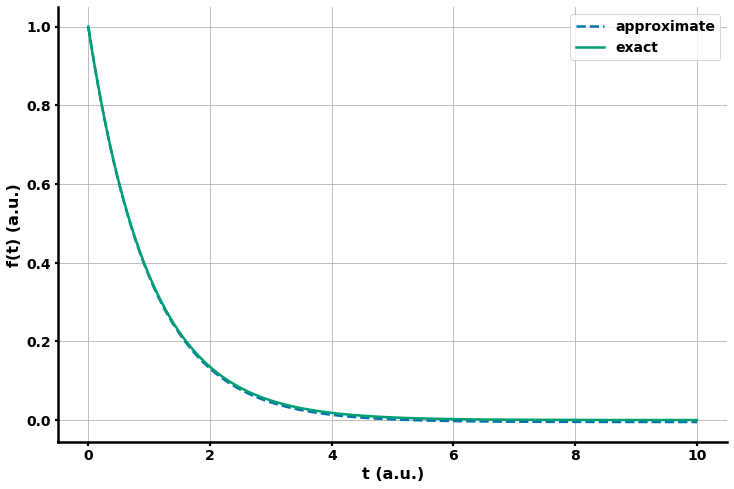

In [3]:
T = 10  # time points (a.u.)
dt = 0.01  # integration step (a.u.)
N = int(T/dt)  # number of steps

# t = np.arange(0, T + dt, dt)  # alternatively we can use np.linspace
t = np.linspace(0, T, N+1)
f_exact = np.exp(-t)

f_approx = np.zeros((N + 1, ))
f_approx[0] = 1  # initial condition
for n in range(N):
  deriv = -np.exp(-n*dt)
  f_approx[n+1] = f_approx[n] + dt*deriv


error = np.mean(f_exact - f_approx)**2
print(f"Mean Squared Error (MSE) is: {np.round(error, 7)}")

plt.figure(figsize=(12, 8))
plt.plot(t, f_approx, label='approximate', linestyle='dashed')
plt.plot(t, f_exact, label='exact')
plt.xlabel('t (a.u.)')
plt.ylabel('f(t) (a.u.)')
plt.legend()
plt.grid()
plt.show()

## Solve RC circuitry numerically

Here, we set $R_m=2000 \Omega, \tau_m=20ms, I_{ext}=0.01mA$.

Notice that, $mA \cdot \Omega = mV$.

The external current, is open at time $t_1$ up until time $t_2$.

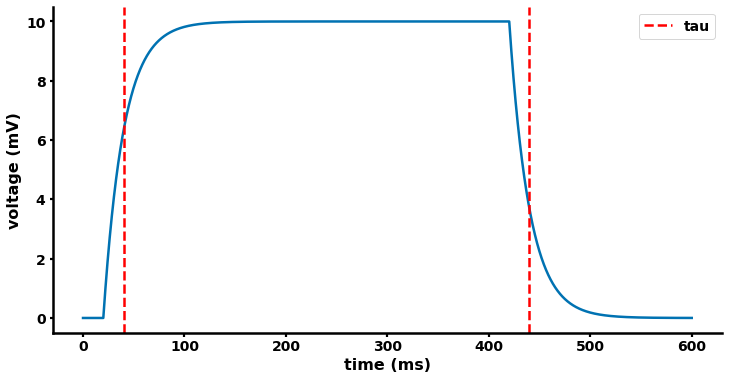

In [15]:
# Euler method

Rm = 2000  # Membrane resistance in Ohm
tau = 20  # membrane time constant in ms
Iinj = 0.005  # mA
dt = 0.1  # integration step in ms
T = 600  # total time in ms
steps = int(T/dt)  # total number of steps
time = np.linspace(0, T, steps+1)  # time vector, in ms

Vm = np.zeros((steps + 1, ))  # voltage vector with zeros
t1 = 20  # stimulus onset in ms
t2 = 420  # stiumulus withdraw in ms

for n in range(steps):
  # After t1 ms and up unitl t2 ms add the external current, else set it to zero
  if n*dt < t1 or n*dt > t2:
    Iext = 0
  else:
    Iext = Iinj  # mA

  deriv = (-Vm[n] + Iext * Rm)/tau
  Vm[n+1] = Vm[n] + dt*deriv

plt.figure(figsize=(12, 6))
plt.plot(time, Vm)
plt.axvline(t1+tau, linestyle='dashed', color='red', label='tau')
plt.axvline(t2+tau, linestyle='dashed', color='red')
plt.xlabel('time (ms)')
plt.ylabel('voltage (mV)')
plt.legend()
plt.show()

On the rise phase, the equation is: 

$V(t) = I_{ext}R_m \left( 1 - \text{exp}(-t/\tau_m) \right)$, so at $t=\tau_m$, the membrane voltage is $V(\tau_m) = I_{ext}R_m (1-\text{exp}(-1))$.

On the decay phase, the equation is:

$V(t) = I_{ext}R_m \text{exp}(-t/\tau_m) $, so at $t=\tau_m$, the membrane voltage is $V(\tau_m) = I_{ext}R_m (\text{exp}(-1))$.

In particular, $\tau_m$ denotes the time membrane needs to reach the 63% of its steady-value (rise-phase) or the time membrane needs to be decreased at the 37% of the initial value (decay phase).



In [24]:
# Calculate the voltage at tau
n1 = int((t1+tau)/dt)  # transform time into step
v_taur = Vm[n1]  # calculate the voltage at n1
print(f"The voltage at tau during rise is: {v_taur}")

n2 = int((t2+tau)/dt)  # transform time into step
v_taud = Vm[n2]  # calculate the voltage at n2
print(f"The voltage at tau during decay is: {v_taud}")

Vss = Iinj * Rm  # steady-state voltage

# Print the percentage of voltage at t=t1+tau, t=t2+tau
print(f"Rise: {np.round(v_taur/Vss, 2)*100}% of the steady-state")
print(f"Decay: {np.round(v_taud/Vss, 2)*100}% of the steady-state")

The voltage at tau during rise is: 6.33042178273832
The voltage at tau during decay is: 3.6880183016122228
Rise: 63.0% of the steady-state
Decay: 37.0% of the steady-state
